# modeling non-Linear patterns w/ activation functions
previously(in notebook 00) we saw simple linear model performed well on bike-only data, but it struggled when cars were added. the reason was simple: your model could only learn **straight lines**, but the new data followed a **curve**. simply adding more linear neurons is not the solution. the model's output would still be a straight line.

> non-linearity:
> this is where **non-linear activation functions** come in. a ReLU activation, allows the model to create multiple "bends" that can approximate the complex delivery time curve.

NOTE:

* includes **normalization** so the model trains more effectively.
* build a *non-linear* neural network using the **ReLU** activation function.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils_new as helper_utils
# make results reproducible and consistent every time.
torch.manual_seed(42)

## non-linear data

this is the combined data for both bike and car deliveries.

In [7]:
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

> the data plot follows a non-linear pattern.

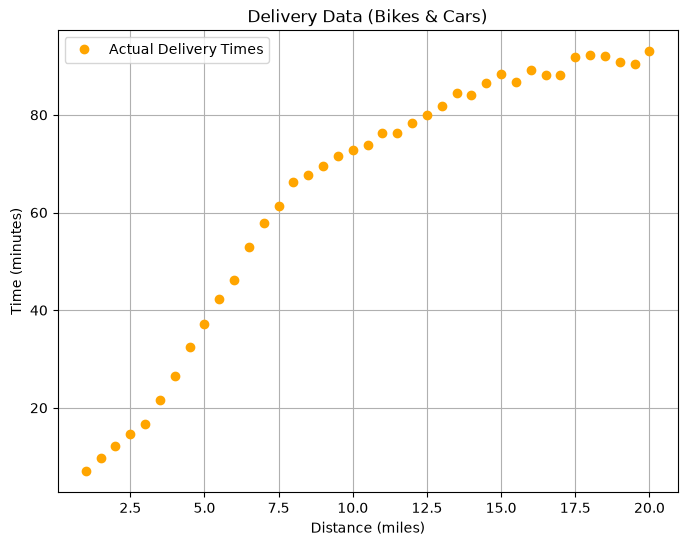

In [8]:
helper_utils.plot_data(distances, times)

### normalizing the data
**normalization**: a standard technique that makes the training process more stable and effective by adjusting the scale of the data. this adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training.

* computes the mean and standard deviation for the `distances` and `times` tensors.
* standardization to each tensor using its respective mean and standard deviation, which creates new normalized tensors named `distances_norm` and `times_norm`.
> this specific technique is called **standardization** (or z-score normalization), which converts the original data from `1.0 to 20.0 miles` and approximately `7 to 93 minutes` into a new, normalized scale.

In [9]:
# mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# standardize the distances.
distances_norm = (distances - distances_mean) / distances_std

# standardize the times.
times_norm = (times - times_mean) / times_std

* NOTE: the axes now show the data on a new, normalized scale, with distance ranging from approximately `-1.7 to 1.7` and time from `-2.0 to 1.0`.
* he underlying curved pattern of the data remains exactly the same regardless.

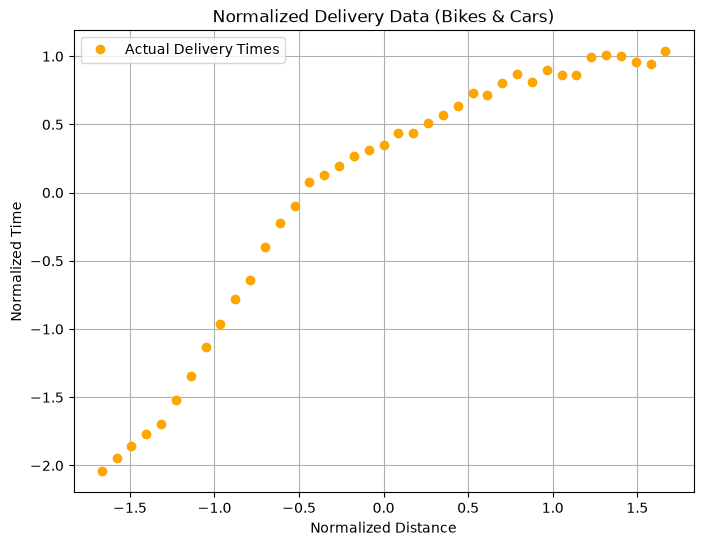

In [10]:
helper_utils.plot_data(distances_norm, times_norm, normalize=True)

## the non-linear model

the model's architecture, which now includes a `ReLU` activation function, gives the model the ability to learn non-linear relationships.

* `nn.Linear(1, 3)`: **first hidden layer**; it consists of three neurons, each receiving one input feature (the normalized distance). this layer transforms the single input value into three separate values.
* `nn.ReLU()` applies the ReLU activation function to the output of each of the three neurons from the hidden layer. this is the non-linear step that allows your model to create "bends" and learn curves instead of just straight lines.
* `nn.Linear(3, 1)`: **output layer**; it takes the three activated values from the previous step as its input and combines them to produce a single final output, which is your predicted (normalized) delivery time.

> this creates a neural network with 1 hidden layer containing 3 neurons.

In [11]:
model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

## training

* define the loss function and the optimizer.

In [12]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

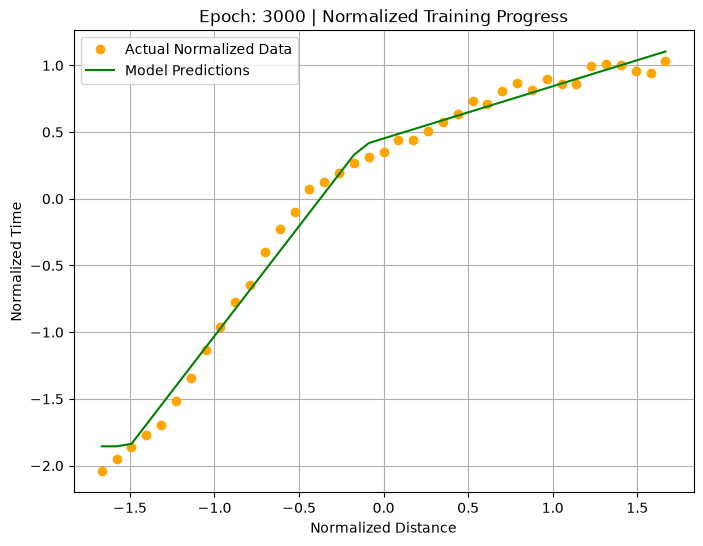


Training Complete.

Final Loss: 0.007795270532369614


In [13]:
# training loop
for epoch in range(3000):
    optimizer.zero_grad()
    # (forward pass)
    outputs = model(distances_norm)
    loss = loss_function(outputs, times_norm)
    # (backward pass)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        helper_utils.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )

print("\nTraining Complete.")
print(f"\nFinal Loss: {loss.item()}")

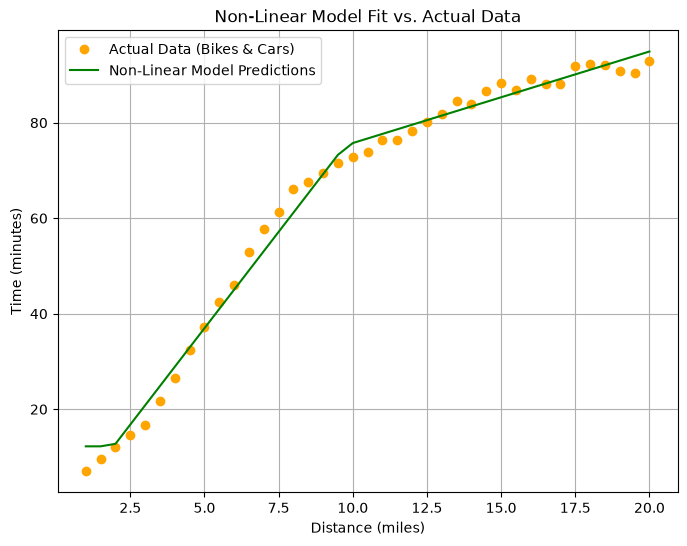

In [14]:
helper_utils.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

## making a prediction

* first off, you take the new input distance and **normalize** it using the same mean and standard deviation from your training data. this step is CRITICAL: your model has no idea about the original scales (miles and minutes). it only understands the normalized scale it was trained on.
* after the model provides its prediction, you must **de-normalize** the output. this converts the prediction from its normalized scale back into an understandable value in minutes.

In [15]:
distance_to_predict = 5.1

In [16]:
with torch.no_grad():
    # normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    
    # get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
    
    # de-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")

    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 37.8 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.


## WRAPS:

saw firsthand how adding a non-linear activation function like **ReLU** gives a model the ability to succeed where a linear model fails.